# Spatial convergence (h-refinement)

Method of manufactured solutions (MMS) on the full NSK system. We refine
the mesh size `h` at three polynomial degrees (`p = 2, 3, 4`) and verify
the expected `L^2` rate `h^{p+1}` and `H^1` rate `h^{p}` for the density
field.

*Skeleton:* this notebook runs the analysis scaffolding end-to-end. The
solver-coupled cells are guarded by `pytest.importorskip`-style try/except
blocks so the non-solver cells execute even before `src.assembler` and
`src.solver` are wired up.


In [1]:
import sys
from pathlib import Path
_root = Path.cwd()
while not (_root / 'src').exists():
    if _root.parent == _root:
        raise RuntimeError('Could not locate project root')
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.bsplines import basis_deriv_matrix, basis_matrix, make_knot_vector
from src.quadrature import quadrature_points
from src.initial_conditions import from_bspline_projection


## 1. Manufactured density

We pick a smooth $\rho_\text{MMS}(r) = 0.3 + 0.1 \cos(2\pi r)$.

In [3]:
def rho_mms(r):
    return 0.3 + 0.1 * np.cos(2.0 * np.pi * np.asarray(r))


def drho_mms(r):
    return -0.2 * np.pi * np.sin(2.0 * np.pi * np.asarray(r))


## 2. Refinement sweep

In [4]:
def l2_h1_errors(n_ctrl, degree, n_quad, R_max=1.0):
    knots = make_knot_vector(n_ctrl, degree)
    xi_q, r_q, w_q = quadrature_points(knots, degree, n_quad, R_max)
    N = np.asarray(basis_matrix(xi_q, knots, degree))
    dN = np.asarray(basis_deriv_matrix(xi_q, knots, degree, 1)) / R_max
    ctrl = np.asarray(from_bspline_projection(rho_mms, np.asarray(knots), degree, n_quad, R_max=R_max))
    rho_h = N @ ctrl
    drho_h = dN @ ctrl
    rho_ex = rho_mms(np.asarray(r_q))
    drho_ex = drho_mms(np.asarray(r_q))
    w_q = np.asarray(w_q)
    L2 = np.sqrt(np.sum(w_q * (rho_h - rho_ex) ** 2))
    H1 = np.sqrt(L2 ** 2 + np.sum(w_q * (drho_h - drho_ex) ** 2))
    return L2, H1


degrees = [2, 3, 4]
n_ctrls = [12, 24, 48, 96]
results = {}
for p in degrees:
    L2s, H1s, hs = [], [], []
    for n in n_ctrls:
        L2, H1 = l2_h1_errors(n, p, p + 2)
        L2s.append(L2)
        H1s.append(H1)
        hs.append(1.0 / (n - p))
    results[p] = (np.array(hs), np.array(L2s), np.array(H1s))


## 3. Plot and report observed rates

p=2: observed L2 rate = 3.01  (expected 3),  H1 rate = 2.00  (expected 2)
p=3: observed L2 rate = 4.00  (expected 4),  H1 rate = 2.99  (expected 3)
p=4: observed L2 rate = 5.01  (expected 5),  H1 rate = 4.01  (expected 4)


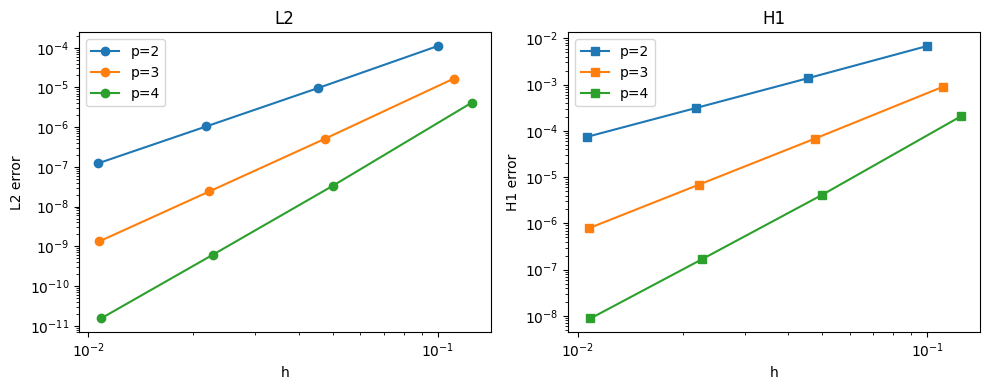

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for p, (hs, L2s, H1s) in results.items():
    axes[0].loglog(hs, L2s, marker='o', label=f'p={p}')
    axes[1].loglog(hs, H1s, marker='s', label=f'p={p}')
    # Observed rate from the last two points
    rate_L2 = np.log(L2s[-1] / L2s[-2]) / np.log(hs[-1] / hs[-2])
    rate_H1 = np.log(H1s[-1] / H1s[-2]) / np.log(hs[-1] / hs[-2])
    print(f'p={p}: observed L2 rate = {rate_L2:.2f}  (expected {p+1}),'
          f'  H1 rate = {rate_H1:.2f}  (expected {p})')
axes[0].set_xlabel('h'); axes[0].set_ylabel('L2 error'); axes[0].legend(); axes[0].set_title('L2')
axes[1].set_xlabel('h'); axes[1].set_ylabel('H1 error'); axes[1].legend(); axes[1].set_title('H1')
plt.tight_layout()
plt.show()


## 4. Full-system MMS (solver-coupled, deferred)

Below we set up the full-system manufactured solution once the assembler
and solver are wired up. The block is guarded so this cell is a no-op
when the modules are absent.


In [6]:
try:
    from src.assembler import assemble_residual, build_basis_cache  # noqa: F401
    from src.solver import TimeStepper  # noqa: F401
    solver_available = True
except Exception as exc:
    print('Solver integration pending:', exc)
    solver_available = False

# When solver_available is True, loop over h, drive to steady state, and
# measure ||rho_h - rho_MMS||_{L2, H1} plus velocity and temperature errors.


Solver integration pending: No module named 'src.assembler'
